# Two-Part Tariff Example

Suppose we have a high-demand consumer with inverse demand given by:

$$
p_h=\alpha - \beta x
$$

and a low-demand consumer with inverse demand given by:

$$
p = \alpha\rho - \epsilon\beta x
$$

We typically imagine that $\epsilon>1>\rho$. This means that the initial willingness to pay is lower for low-demand consumers, and also that their WTP falls faster than that of high demand consumers.

## Charging tariffs

The way things work is we charge the consumers tariffs which are proportional to their Consumer surplus. Remember the basic setup is one where we have a two part tariff that is set up as is shown in the diagram below. In the diagram, we see that the high type is able to capture some consumer surplus, while the low type has all their surplus extracted. In my example, we have assumed the marginal costs are zero, so we don't have the usual component where we produce up to the point where price equals marginal costs.

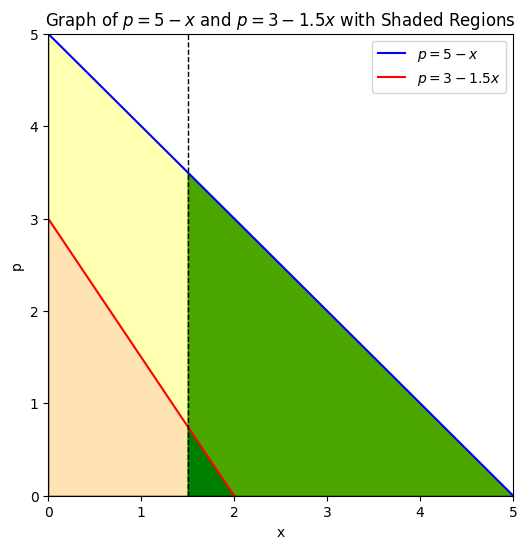

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for x values
x = np.linspace(0, 5, 100)

# Define the two functions
p1 = 5 - x
p2 = 3 - 1.5 * x

# Create the plot
plt.figure(figsize=(6, 6))
plt.plot(x, p1, label=r'$p = 5 - x$', color='blue')
plt.plot(x, p2, label=r'$p = 3 - 1.5x$', color='red')

# Add vertical dashed line at x = 1.5
plt.axvline(1.5, color='black', linestyle='dashed', linewidth=1)

# Shade the region under p = 3 - 1.5x to the left of x = 1.5 in orange (transparent)
x_fill_left = np.linspace(0, 1.5, 100)
p_fill_left = 3 - 1.5 * x_fill_left
plt.fill_between(x_fill_left, p_fill_left, 0, color='orange', alpha=0.3)

# Shade the region under p = 5 - x to the right of x = 1.5 in green (opaque)
x_fill_right = np.linspace(1.5, 5, 100)
p_fill_right = 5 - x_fill_right
plt.fill_between(x_fill_right, p_fill_right, 0, color='green', alpha=1.0)

# Shade the region between the two curves in yellow
x_fill_between = np.linspace(0, 5, 100)
plt.fill_between(x_fill_between, p1, p2, where=(p1 >= p2), color='yellow', alpha=0.3)

# Add axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Limit the axes to only show the relevant part
plt.xlim(0, 5)
plt.ylim(0, 5)

# Labels and title
plt.xlabel('x')
plt.ylabel('p')
plt.title('Graph of $p = 5 - x$ and $p = 3 - 1.5x$ with Shaded Regions')

# Show the legend
plt.legend()

# Show the plot
plt.show()



In the above, remember the following:

1) The dark green small triangle plus the orange triangle is the total consumer surplus of a low type.
2) Orange, plus green, plus yellow is the total consumer surplus of the high type.
3) The low type will be offered a consumption bundle something like where the dashed line is; at a price corresponding to the orange trapezoid, which is all of the low type's surplus.
4) The high type will be offered a bundle of 5, and charged the fee corresponding to the orange plus the green shape. The high type, therefore, walks away with a surplus equal to the yellow trapezoid.

## Incentive compatibility

We offer $x_h$ according to $0 = \alpha - \beta x_h$, or $x_h=\frac{\alpha}{\beta}$. Then, given an $x_l$, we have a total area for the green triangle as:

$$
T_h=\frac{(x_h-x_l)(\alpha-\beta x_l)}{2}=\frac{(\frac{\beta}{\alpha}-x_l)(\alpha-\beta x_l)}{2}
$$
The area of the orange trapezoid follows from it having (sideways) a height of $x_l$, a lower base of $ \rho\alpha$, and an upper base of $\alpha\rho-\epsilon\beta x_l$. So:
$$
T_l=x_l\frac{\left(\rho\alpha + \rho\alpha - \epsilon\beta x_l\right)}{2}
$$

Now, revenues are $\lambda (T_h+T_l) + (1-\lambda)T_l$, where $\lambda is is the fraction of high-demand consumers in the population. Let's work it out:



In [3]:
from sympy import *

xl, alpha, beta, rho, epsilon, lam = symbols('x_l alpha beta rho epsilon lambda')

In [ ]:
Th = (alpha/beta-xl)*(alpha-beta*xl)/2
Th

(alpha - beta*x_l)*(alpha/beta - x_l)/2

In [ ]:
Tl = xl*(rho*alpha + rho*alpha - epsilon*beta*xl)/2
Tl

x_l*(2*alpha*rho - beta*epsilon*x_l)/2

In [ ]:
maximand = lam*(Th+Tl) + (1-lam)*Tl
maximand.simplify()

alpha*rho*x_l - beta*epsilon*x_l**2/2 + lambda*(alpha - beta*x_l)**2/(2*beta)

In [ ]:
xlsta = solve(diff(maximand, xl).simplify(), xl)[0]
xlsta.factor()

-alpha*(lambda - rho)/(beta*(epsilon - lambda))

In [ ]:
Theq = Th.subs({xl:xlsta}).simplify()
Tleq = Tl.subs({xl:xlsta}).simplify()

In [ ]:
parms = {alpha:5, beta:1, epsilon:1.1, rho:.6, lam:.5}

In [ ]:
Theq.subs(parms), Tleq.subs(parms), xlsta.subs(parms)

(8.68055555555556, 2.11805555555556, 0.833333333333333)

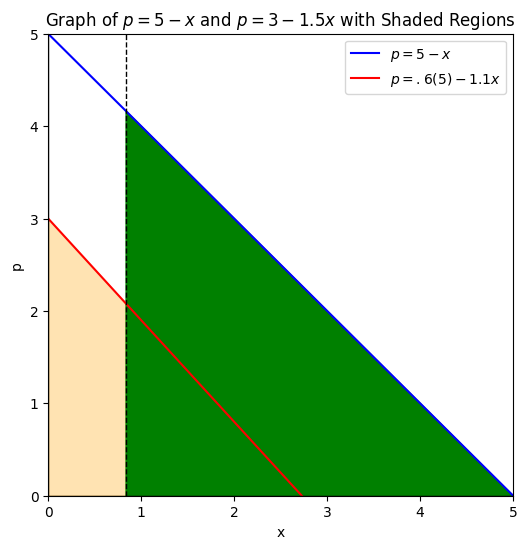

In [ ]:
# Plot of the solution
x = np.linspace(0, 5, 100)

# Define the two functions
p1 = 5 - x
p2 = 5*.6 - 1.1 * x

# Create the plot
plt.figure(figsize=(6, 6))
plt.plot(x, p1, label=r'$p = 5 - x$', color='blue')
plt.plot(x, p2, label=r'$p = .6(5) - 1.1x$', color='red')

# Add vertical dashed line at x = 1.5
plt.axvline(.8333, color='black', linestyle='dashed', linewidth=1)

# Shade the region under p = 3 - 1.5x to the left of x = 1.5 in orange (transparent)
x_fill_left = np.linspace(0, .833, 100)
p_fill_left = 5*.6 - 1.1 * x_fill_left
plt.fill_between(x_fill_left, p_fill_left, 0, color='orange', alpha=0.3)

# Shade the region under p = 5 - x to the right of x = 1.5 in green (opaque)
x_fill_right = np.linspace(.833, 5, 100)
p_fill_right = 5 - x_fill_right
plt.fill_between(x_fill_right, p_fill_right, 0, color='green', alpha=1.0)

# Add axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Limit the axes to only show the relevant part
plt.xlim(0, 5)
plt.ylim(0, 5)

# Labels and title
plt.xlabel('x')
plt.ylabel('p')
plt.title('Graph of $p = 5 - x$ and $p = 3 - 1.5x$ with Shaded Regions')

# Show the legend
plt.legend()

# Show the plot
plt.show()